# 02 — VWAP Bounce Strategy: Señales y Backtest

Este notebook implementa la estrategia VWAP Bounce descrita en `spec.md`. Incluye generación de señales, simulación de operaciones con `take-profit`, `stop-loss` y `timeout`, y comparación contra Buy & Hold.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from curso.lib import download_historical
from datetime import timedelta

pd.options.display.float_format = '{:,.6f}'.format

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
# Parámetros de la estrategia
TICKERS = ['AAPL','MSFT','SPY']
START = '2020-01-01'
END = '2025-12-31'
VWAP_ROLLING_WINDOW = 20
SMA_TREND = 200
VWAP_TOLERANCE_PCT = 0.005  # 0.5%
TAKE_PROFIT_PCT = 0.02
STOP_LOSS_PCT = 0.02
TIMEOUT_DAYS = 10

In [3]:
# Reutilizar cálculo de VWAP (similar al notebook 01)
def compute_vwap(df, rolling_window=VWAP_ROLLING_WINDOW):
    df = df.copy()
    if 'Volume' not in df.columns and 'volume' in df.columns:
        df['Volume'] = df['volume']
    df['typical_price'] = (df['High'] + df['Low'] + df['Close'])/3.0
    vol = df['Volume'].replace(0, np.nan)
    df['VWAP_cumulative'] = (df['typical_price'] * vol).cumsum() / vol.cumsum()
    tp_vol = df['typical_price'] * vol
    df['VWAP_rolling'] = tp_vol.rolling(rolling_window).sum() / vol.rolling(rolling_window).sum()
    df['SMA_'+str(SMA_TREND)] = df['Close'].rolling(SMA_TREND).mean()
    return df

In [4]:
# Descargar datos
data = {}
for t in TICKERS:
    df = download_historical(t, start_date=START, end_date=END, use_cache=True)
    data[t] = compute_vwap(df)
    print(t, data[t].shape)

AAPL (1255, 9)
MSFT (1255, 9)
SPY (1255, 9)


In [5]:
# Generar señales y simular operaciones por ticker
from dataclasses import dataclass

@dataclass
class Trade:
    entry_date: pd.Timestamp
    exit_date: pd.Timestamp
    ticker: str
    side: str
    entry_price: float
    exit_price: float
    pnl_pct: float
    duration: int
    exit_reason: str

def run_strategy_on_df(df, ticker):
    trades = []
    in_position = False
    i = 0
    dates = df.index
    while i < len(dates):
        date = dates[i]
        row = df.loc[date]
        close = row['Close']
        vwap = row['VWAP_cumulative']
        sma = row.get('SMA_'+str(SMA_TREND), np.nan)

        # Condiciones de señal
        close_rising = False
        if i>0:
            close_rising = close > df['Close'].iloc[i-1]

        buy_signal = (not in_position) and (not np.isnan(vwap)) and (close > sma) and close_rising and (abs(close - vwap)/vwap < VWAP_TOLERANCE_PCT)
        short_signal = (not in_position) and (not np.isnan(vwap)) and (close < sma) and (not close_rising) and (abs(close - vwap)/vwap < VWAP_TOLERANCE_PCT)

        if buy_signal:
            entry_price = close
            tp = entry_price * (1 + TAKE_PROFIT_PCT)
            sl = entry_price * (1 - STOP_LOSS_PCT)
            # Buscar salida en los próximos TIMEOUT_DAYS
            exit_idx = min(i + TIMEOUT_DAYS, len(dates)-1)
            exit_reason = 'timeout'
            exit_price = df['Close'].iloc[exit_idx]
            for j in range(i+1, exit_idx+1):
                high = df['High'].iloc[j]
                low = df['Low'].iloc[j]
                if high >= tp:
                    exit_price = tp
                    exit_reason = 'tp'
                    exit_idx = j
                    break
                if low <= sl:
                    exit_price = sl
                    exit_reason = 'sl'
                    exit_idx = j
                    break
            pnl = (exit_price / entry_price) - 1
            trades.append(Trade(entry_date=date, exit_date=dates[exit_idx], ticker=ticker, side='long', entry_price=entry_price, exit_price=exit_price, pnl_pct=float(pnl), duration=(exit_idx - i), exit_reason=exit_reason))
            in_position = False
            i = exit_idx + 1
            continue

        if short_signal:
            entry_price = close
            tp = entry_price * (1 - TAKE_PROFIT_PCT)
            sl = entry_price * (1 + STOP_LOSS_PCT)
            exit_idx = min(i + TIMEOUT_DAYS, len(dates)-1)
            exit_reason = 'timeout'
            exit_price = df['Close'].iloc[exit_idx]
            for j in range(i+1, exit_idx+1):
                high = df['High'].iloc[j]
                low = df['Low'].iloc[j]
                # para short: si low <= tp (lower price) alcanzado, o high >= sl (stop losed)
                if low <= tp:
                    exit_price = tp
                    exit_reason = 'tp'
                    exit_idx = j
                    break
                if high >= sl:
                    exit_price = sl
                    exit_reason = 'sl'
                    exit_idx = j
                    break
            pnl = (entry_price / exit_price) - 1
            trades.append(Trade(entry_date=date, exit_date=dates[exit_idx], ticker=ticker, side='short', entry_price=entry_price, exit_price=exit_price, pnl_pct=float(pnl), duration=(exit_idx - i), exit_reason=exit_reason))
            in_position = False
            i = exit_idx + 1
            continue

        i += 1
    return trades

In [6]:
# Ejecutar estrategia para todos los tickers y compilar resultados
all_trades = []
for t, df in data.items():
    trades = run_strategy_on_df(df, t)
    all_trades.extend(trades)
    print(t, 'trades:', len(trades))

trades_df = pd.DataFrame([t.__dict__ for t in all_trades])
if not trades_df.empty:
    trades_df['pnl_pct'] = trades_df['pnl_pct'].astype(float)
    display(trades_df.head())
else:
    print('No se generaron trades.')

AAPL trades: 8
MSFT trades: 4
SPY trades: 6


,entry_date,exit_date,ticker,side,entry_price,exit_price,pnl_pct,duration,exit_reason
0,2022-04-26,2022-04-28,AAPL,short,156.800003,159.936003,-0.019608,2,sl
1,2022-04-29,2022-05-02,AAPL,short,157.649994,154.496994,0.020408,1,tp
2,2022-05-05,2022-05-09,AAPL,short,156.770004,153.634604,0.020408,2,tp
3,2022-07-22,2022-07-26,AAPL,short,154.089996,151.008196,0.020408,2,tp
4,2022-09-02,2022-09-08,AAPL,short,155.809998,152.693798,0.020408,3,tp


In [7]:
# Calcular métricas sencillas de desempeño
def performance_metrics(trades_df):
    n = len(trades_df)
    wins = (trades_df['pnl_pct'] > 0).sum()
    win_rate = wins / n if n>0 else None
    avg_pnl = trades_df['pnl_pct'].mean() if n>0 else None
    total_return = (1 + trades_df['pnl_pct']).prod() - 1 if n>0 else None
    # Equity curve simple (actualizado al cierre de cada trade)
    if n>0:
        equity = [1.0]
        for p in trades_df['pnl_pct']:
            equity.append(equity[-1] * (1 + p))
        equity = equity[1:]
        peak = np.maximum.accumulate(equity)
        dd = (equity - peak) / peak
        max_dd = dd.min()
    else:
        equity = []
        max_dd = None
    return dict(n=n, wins=wins, win_rate=win_rate, avg_pnl=avg_pnl, total_return=total_return, max_dd=max_dd)

metrics = performance_metrics(trades_df) if not trades_df.empty else {}
metrics

{'n': 18,
 'wins': 11,
 'win_rate': 0.6111111111111112,
 'avg_pnl': 0.0044835914769090456,
 'total_return': 0.08020881760520426,
 'max_dd': -0.03921568627450978}

In [8]:
# Comparación con Buy & Hold (por ticker)
bh = []
for t, df in data.items():
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]
    ret = end_price / start_price - 1
    bh.append({'ticker': t, 'bh_return': ret})
display(pd.DataFrame(bh).set_index('ticker'))

,bh_return
ticker,
AAPL,1.478930
MSFT,0.884715
SPY,0.798254


/var/folders/zw/_9_z_l6x04d1k88c2d84lwym0000gp/T/ipykernel_73308/3432655622.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bh_comb = pd.concat(bh_series, axis=1).fillna(method='ffill').mean(axis=1)


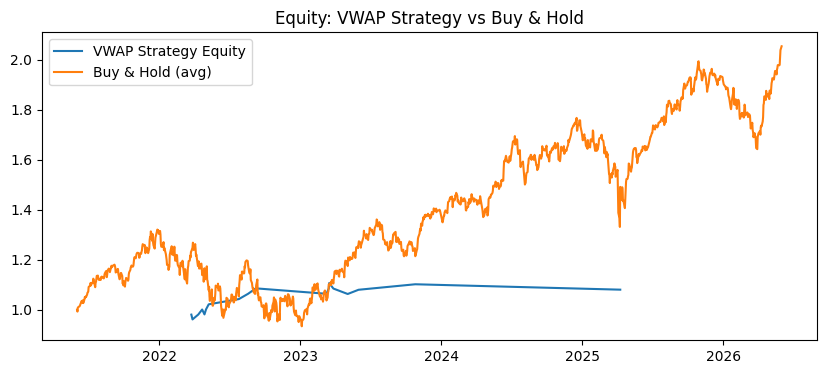

In [9]:
# Equity curve y resumen final
if not trades_df.empty:
    trades_df_sorted = trades_df.sort_values('exit_date')
    equity_dates = [pd.to_datetime(trades_df_sorted['exit_date'].iloc[0])]
    equity_values = [1.0]
    for p, d in zip(trades_df_sorted['pnl_pct'], trades_df_sorted['exit_date']):
        equity_values.append(equity_values[-1] * (1 + p))
        equity_dates.append(pd.to_datetime(d))
    eqs = pd.Series(equity_values[1:], index=equity_dates[1:])
    plt.figure(figsize=(10,4))
    plt.plot(eqs.index, eqs.values, label='VWAP Strategy Equity')
    # Añadir buy & hold equity (normalizada) promediada entre tickers
    bh_series = []
    for t, df in data.items():
        s = df['Close'] / df['Close'].iloc[0]
        s.index = pd.to_datetime(s.index)
        bh_series.append(s)
    # combinar por unión y promediar (rellenar NA hacia adelante)
    if bh_series:
        bh_comb = pd.concat(bh_series, axis=1).fillna(method='ffill').mean(axis=1)
        # normalizar para empezar en 1 en la fecha inicial de eqs (si existe)
        common_start = min(bh_comb.index[0], eqs.index[0])
        bh_norm = bh_comb / bh_comb.iloc[0]
        plt.plot(bh_norm.index, bh_norm.values, label='Buy & Hold (avg)')
    plt.legend()
    plt.title('Equity: VWAP Strategy vs Buy & Hold')
    plt.show()
else:
    print('No equity to plot.')

In [10]:
# === Fase 5: VWAP Multi-Temporal y Detección de Confluencia
# Resamplear a semanal y mensual, calcular VWAP por temporalidad
vwap_frames = {}
for t, df in data.items():
    daily = df.copy()
    weekly = df[['Open','High','Low','Close','Volume']].resample('W').agg({'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'}).dropna()
    monthly = df[['Open','High','Low','Close','Volume']].resample('M').agg({'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'}).dropna()
    for name, r in [('weekly', weekly), ('monthly', monthly)]:
        r = r.copy()
        r['typical_price'] = (r['High'] + r['Low'] + r['Close'])/3.0
        vol = r['Volume'].replace(0, np.nan)
        r['VWAP'] = (r['typical_price'] * vol).cumsum() / vol.cumsum()
        if t not in vwap_frames:
            vwap_frames[t] = {}
        vwap_frames[t][name] = r[['VWAP']]
    vwap_frames[t]['daily'] = daily[['VWAP_cumulative']].rename(columns={'VWAP_cumulative':'VWAP'})

print('Resampled VWAP frames computed for', list(vwap_frames.keys()))

# Detectar zonas de confluencia: cuando 2+ VWAPs están dentro de 1% entre sí
CONFLUENCE_PCT = 0.01
confluence_zones = {}
for t, frames in vwap_frames.items():
    daily_idx = data[t].index
    df_map = pd.DataFrame(index=daily_idx)
    df_map['vwap_daily'] = frames['daily'].reindex(daily_idx).ffill()['VWAP']
    df_map['vwap_weekly'] = frames['weekly'].reindex(daily_idx, method='ffill')['VWAP']
    df_map['vwap_monthly'] = frames['monthly'].reindex(daily_idx, method='ffill')['VWAP']
    def count_confluence(row):
        vals = [row['vwap_daily'], row['vwap_weekly'], row['vwap_monthly']]
        vals = [v for v in vals if not pd.isna(v)]
        cnt = 0
        for i in range(len(vals)):
            for j in range(i+1, len(vals)):
                if abs(vals[i] - vals[j])/vals[i] < CONFLUENCE_PCT:
                    cnt += 1
        if cnt >= 2:
            return 3
        if cnt == 1:
            return 2
        return 1 if len(vals)>0 else 0
    df_map['aligned_count'] = df_map.apply(count_confluence, axis=1)
    zones = df_map[df_map['aligned_count']>=2].copy()
    confluence_zones[t] = zones[['vwap_daily','vwap_weekly','vwap_monthly','aligned_count']]
    print(f'{t}: confluence days =', len(zones))

print('Confluence detection completed.')

# Generar señales basadas en confluencia: BUY cuando precio > todos los VWAPs alineados en la zona y la tendencia (SMA) es alcista
confluence_trades = []
for t, zones in confluence_zones.items():
    df = data[t]
    for date, row in zones.iterrows():
        if date not in df.index:
            continue
        price = df.loc[date]['Close']
        sma = df.loc[date].get('SMA_'+str(SMA_TREND), np.nan)
        vds = [row['vwap_daily'], row['vwap_weekly'], row['vwap_monthly']]
        vds_clean = [v for v in vds if not pd.isna(v)]
        if len(vds_clean) < 2:
            continue
        if price > max(vds_clean) and (not pd.isna(sma)) and price > sma:
            start_idx = df.index.get_loc(date)
            entry_price = df.iloc[start_idx]['Close']
            tp = entry_price*(1+TAKE_PROFIT_PCT)
            sl = entry_price*(1-STOP_LOSS_PCT)
            exit_idx = min(start_idx + TIMEOUT_DAYS, len(df)-1)
            exit_price = df.iloc[exit_idx]['Close']
            exit_reason = 'timeout'
            for j in range(start_idx+1, exit_idx+1):
                if df['High'].iloc[j] >= tp:
                    exit_price = tp; exit_idx = j; exit_reason='tp'; break
                if df['Low'].iloc[j] <= sl:
                    exit_price = sl; exit_idx = j; exit_reason='sl'; break
            pnl = (exit_price/entry_price)-1
            confluence_trades.append(Trade(entry_date=date, exit_date=df.index[exit_idx], ticker=t, side='long', entry_price=float(entry_price), exit_price=float(exit_price), pnl_pct=float(pnl), duration=(exit_idx-start_idx), exit_reason=exit_reason))

con_df = pd.DataFrame([c.__dict__ for c in confluence_trades])
print('Confluence trades count:', len(confluence_trades))
if not con_df.empty:
    display(con_df.head())
    print('Confluence trade metrics:', performance_metrics(con_df))
else:
    print('No confluence trades generated.')


Resampled VWAP frames computed for ['AAPL', 'MSFT', 'SPY']
AAPL: confluence days = 1248
MSFT: confluence days = 1250
SPY: confluence days = 1252
Confluence detection completed.


/var/folders/zw/_9_z_l6x04d1k88c2d84lwym0000gp/T/ipykernel_73308/3986683031.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df[['Open','High','Low','Close','Volume']].resample('M').agg({'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'}).dropna()
/var/folders/zw/_9_z_l6x04d1k88c2d84lwym0000gp/T/ipykernel_73308/3986683031.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df[['Open','High','Low','Close','Volume']].resample('M').agg({'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'}).dropna()
/var/folders/zw/_9_z_l6x04d1k88c2d84lwym0000gp/T/ipykernel_73308/3986683031.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df[['Open','High','Low','Close','Volume']].resample('M').agg({'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'}).d

Confluence trades count: 2015


,entry_date,exit_date,ticker,side,entry_price,exit_price,pnl_pct,duration,exit_reason
0,2022-03-16,2022-03-18,AAPL,long,159.589996,162.781796,0.020000,2,tp
1,2022-03-17,2022-03-18,AAPL,long,160.619995,163.832395,0.020000,1,tp
2,2022-03-18,2022-03-22,AAPL,long,163.979996,167.259596,0.020000,2,tp
3,2022-03-21,2022-03-22,AAPL,long,165.380005,168.687605,0.020000,1,tp
4,2022-03-22,2022-03-23,AAPL,long,168.820007,172.196407,0.020000,1,tp


Confluence trade metrics: {'n': 2015, 'wins': 1143, 'win_rate': 0.5672456575682382, 'avg_pnl': 0.0023045674395736114, 'total_return': 70.92372310586124, 'max_dd': -0.5515356030775755}


## Limitaciones y próximos pasos

- La simulación es simplificada: entradas y salidas usan precios intradía (High/Low) heurísticos basados en la vela siguiente, no deslizamiento ni comisiones.
- Mejoras: incluir coste de transacción, size management, slippage, test por intervalo rolling y validación out-of-sample.